In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, auc, roc_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns


**KDDCup'99 Dataset:**

This is the data set used for The Third International Knowledge Discovery and Data Mining Tools Competition, which was held in conjunction with KDD-99 The Fifth International Conference on Knowledge Discovery and Data Mining. The competition task was to build a network intrusion detector, a predictive model capable of distinguishing between “bad” connections, called intrusions or attacks, and “good” normal connections. This database contains a standard set of data to be audited, which includes a wide variety of intrusions simulated in a military network environment

In [ ]:

# -----------------------------
# 1. Load and preprocess dataset
# -----------------------------
X, y = fetch_kddcup99(return_X_y=True, as_frame=True)
data = pd.DataFrame(X)
target = pd.Series(y)

print(data.head)
print(data.shape)
print(target.shape)


In [ ]:
# Collapse into binary: normal = 0, attack = 1
target_binary = target.apply(lambda lbl: 0 if lbl == b'normal.' else 1)

print("Unique labels in binary target:", target_binary.unique())
print("Counts:\n", target_binary.value_counts())

Unique labels in binary target: [0 1]
Counts:
 labels
1    396743
0     97278
Name: count, dtype: int64


In [ ]:
# Handle missing values
data = data.fillna(data.mean(numeric_only=True))

In [ ]:
# Remove duplicates
data = data.drop_duplicates()
target_binary = target_binary.loc[data.index]


In [ ]:
print(data.shape)
print(target_binary.shape)

(145584, 41)
(145584,)


In [ ]:
# Encode categorical features (Label Encoder)
for col in data.select_dtypes(include=['object']).columns:
    # Convert bytes to string before encoding
    data[col] = data[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

In [ ]:
print(data.head)

<bound method NDFrame.head of         duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
0              0              1       22     9        164       4773     0   
1              0              1       22     9        222        465     0   
2              0              1       22     9        218       1316     0   
3              0              1       22     9        202       1316     0   
4              0              1       22     9        200       2006     0   
...          ...            ...      ...   ...        ...        ...   ...   
494016         0              1       22     9        293       1856     0   
494017         0              1       22     9        265       2254     0   
494018         0              1       22     9        186       1179     0   
494019         0              1       22     9        274       1179     0   
494020         0              1       22     9        202       1213     0   

        wrong_fragment  urgent  h

In [ ]:
target = target_binary.values  # keep as 0/1 integers

In [ ]:
# Balance classes with SMOTE (Synthetic Minority Over-Sampling Technique)
smote = SMOTE(random_state=42, k_neighbors=1)
X_resampled, y_resampled = smote.fit_resample(data, target)

In [ ]:
print(X_resampled.shape)

(175664, 41)


In [ ]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

In [ ]:
# PCA dimensionality reduction
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print(X_pca.shape)

(175664, 23)


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)


**Isolation Forest:**

It is a tree-based ensemble model. It achieved a training accuracy of 0.487, which is consistent with its unsupervised nature and the ability to isolate anomalies in shorter decision paths. Its test accuracy of 0.484 indicates poor generalization to unseen data. This limitation is due to the complexity and heterogeneity of the dataset, which may impede the detection of subtle patterns in network traffic anomalies

In [ ]:

iso = IsolationForest(random_state=42)
#"IsolationForest": {"n_estimators": [100, 200], "contamination": [0.05, 0.1]},
param_grid_iso = {"n_estimators": [100, 200], "contamination": [0.05, 0.1]}

search_iso = RandomizedSearchCV(
    iso, param_grid_iso, cv=5, scoring='f1_macro', n_jobs=-1, n_iter=5, random_state=42
)
search_iso.fit(X_train)
best_iso = search_iso.best_estimator_


Isolation Forest Train Accuracy: 0.48700998356234565
Isolation Forest Test Accuracy: 0.48427404434577176




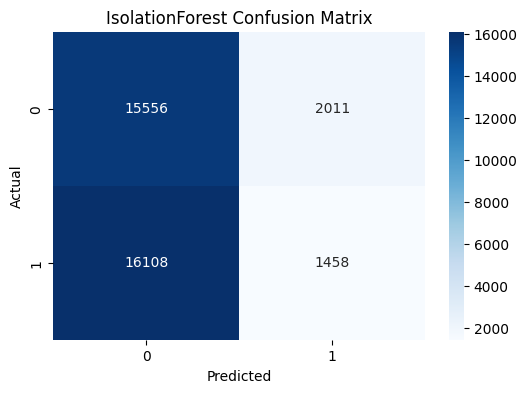

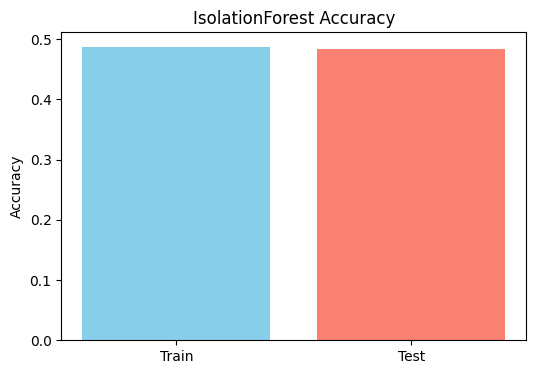

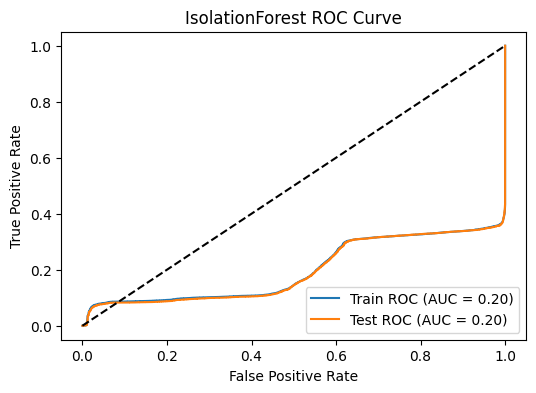

In [ ]:

# Predictions
y_train_pred = best_iso.predict(X_train)
y_test_pred = best_iso.predict(X_test)

# IsolationForest outputs: -1 = anomaly, 1 = normal
# Convert to binary labels: 0 = normal, 1 = attack
y_train_pred = (y_train_pred == -1).astype(int)
y_test_pred = (y_test_pred == -1).astype(int)

# Metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print("Isolation Forest Train Accuracy:", train_acc)
print("Isolation Forest Test Accuracy:", test_acc)

print("\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("IsolationForest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n")

# Accuracy Bar Graph
plt.figure(figsize=(6,4))
plt.bar(["Train","Test"], [train_acc, test_acc], color=['skyblue','salmon'])
plt.title("IsolationForest Accuracy")
plt.ylabel("Accuracy")
plt.show()

print("\n")

# ROC Curve (since IsolationForest doesn't have predict_proba, use decision_function)
y_train_scores = -best_iso.decision_function(X_train)  # higher = more anomalous
y_test_scores = -best_iso.decision_function(X_test)

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_scores)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_scores)
roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(6,4))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {roc_auc_train:.2f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {roc_auc_test:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title("IsolationForest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


**Naive Bayes:**

Known for its simpler and faster training, is able to make sense of the patterns and correlations in our data as we can see from the spread (0.95 → 0.82) indicates the model is sensitive to the data distribution while using 5-fold Cross-Validation and gives a mean accuracy of 0.91. Naive Bayes uses probability concepts, where the probabilities of an example belonging to particular classes are calculated given their attributes. This makes them especially good for working with high-dimensional data, which most network traffic datasets are. But, its independence assumption can cause performance swings when feature correlations differ between folds.

In [ ]:

nb = GaussianNB(var_smoothing=1e-9)
#"NaiveBayes": {"var_smoothing": np.logspace(0,-9, num=100)},
nb.fit(X_train, y_train)


GaussianNB()

Cross-validated Accuracy scores: [0.91577719 0.95522728 0.94805454 0.9301796  0.92414323]
Mean Accuracy: 0.9346763677638188




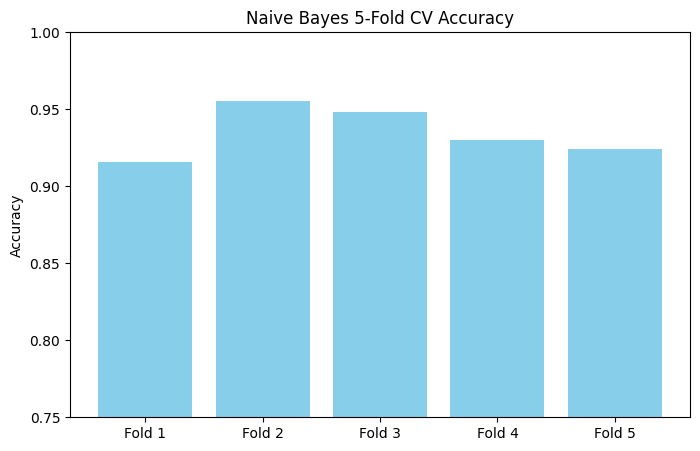

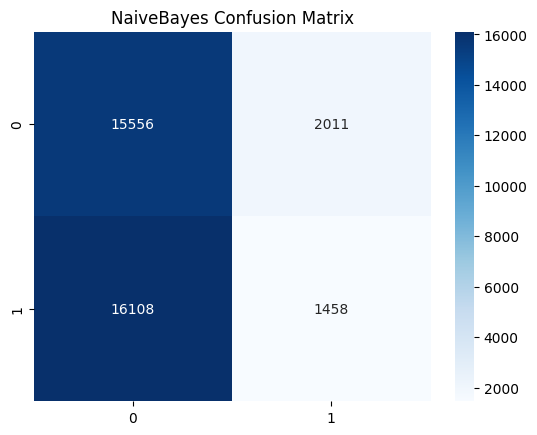

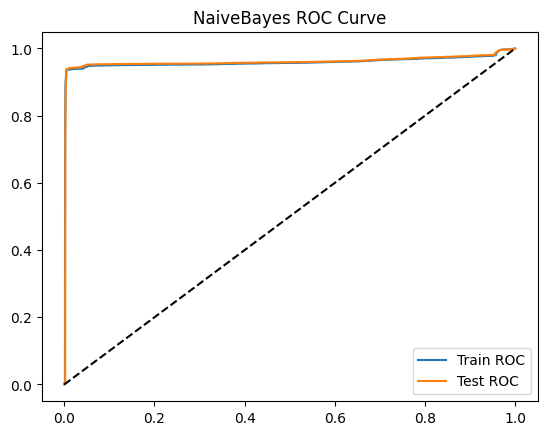

In [ ]:
# Accuracy with 5-fold CV
acc_scores = cross_val_score(nb, X_pca, y_resampled, cv=5, scoring='accuracy')
print("Cross-validated Accuracy scores:", acc_scores)
print("Mean Accuracy:", acc_scores.mean())

print("\n")

plt.figure(figsize=(8,5))
plt.bar(range(1,6), acc_scores, color='skyblue')
plt.xticks(range(1,6), [f'Fold {i}' for i in range(1,6)])
plt.ylabel('Accuracy')
plt.title('Naive Bayes 5-Fold CV Accuracy')
plt.ylim(0.75,1.0)  # set y-axis range for clarity
plt.show()

print("\n")

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("NaiveBayes Confusion Matrix")
plt.show()

print("\n")

# ROC Curve
y_train_proba = nb.predict_proba(X_train)[:,1]
y_test_proba = nb.predict_proba(X_test)[:,1]
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
plt.plot(fpr_train, tpr_train, label="Train ROC")
plt.plot(fpr_test, tpr_test, label="Test ROC")
plt.plot([0,1],[0,1],'k--')
plt.legend(); plt.title("NaiveBayes ROC Curve"); plt.show()


**XGBoost:**

One of the interesting outcomes is results obtained with XG Boost (an implementation of gradient boosting). XG Boost showed very good training and testing accuracies (train accuracy: 0.9984, test accuracy: 0.9982). It worked pretty well, because due to the ensemble of weak learners it learned from complex correlations in data. A good result for the test dataset and high accuracy suggests that XG Boost has been able to predict aberrant patterns and makes it a prime choice in network traffic anomaly detection


In [ ]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', learning_rate=0.01, max_depth=10, n_estimators=100)
#"XGBoost": {"learning_rate": [0.01, 0.1], "max_depth": [5, 10], "n_estimators": [100, 200]},
xgb.fit(X_train, y_train)

y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:40:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Train Acc: 0.9984273932441953
XGBoost Test Acc: 0.9982068141063957




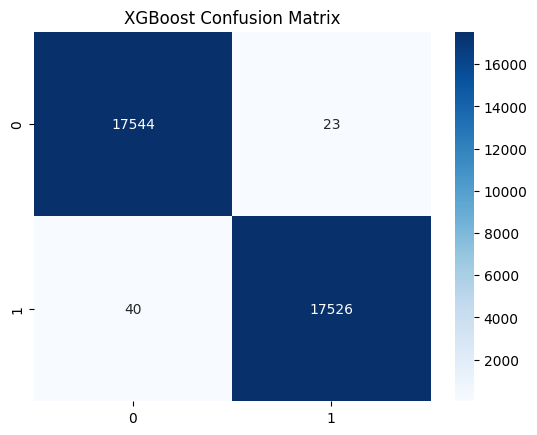

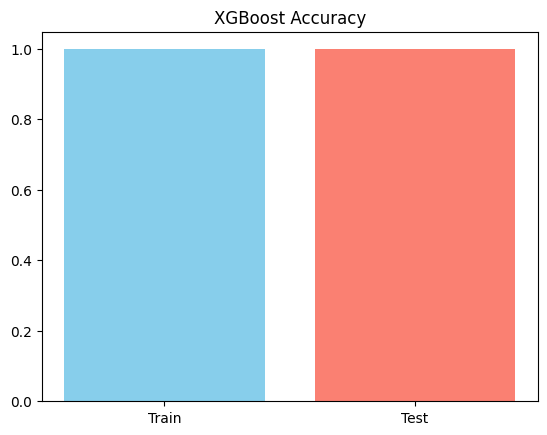

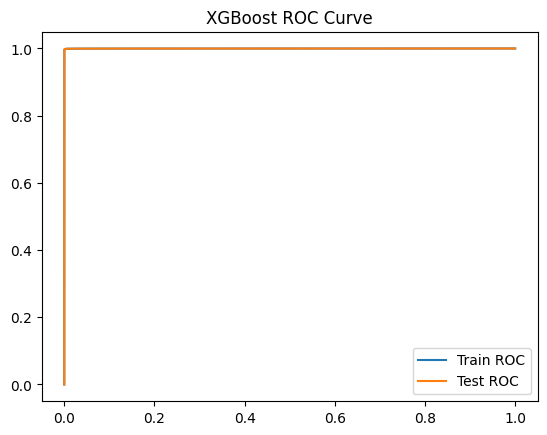

In [ ]:

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print("XGBoost Train Acc:", train_acc)
print("XGBoost Test Acc:", test_acc)

print("\n")

#Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix"); plt.show()

print("\n")

#Bar graph
plt.bar(["Train","Test"], [train_acc, test_acc], color=['skyblue','salmon'])
plt.title("XGBoost Accuracy"); plt.show()

print("\n")

#ROC Curve
y_train_proba = xgb.predict_proba(X_train)[:,1]
y_test_proba = xgb.predict_proba(X_test)[:,1]
plt.plot(*roc_curve(y_train, y_train_proba)[:2], label="Train ROC")
plt.plot(*roc_curve(y_test, y_test_proba)[:2], label="Test ROC")
plt.legend(); plt.title("XGBoost ROC Curve"); plt.show()


**LightGBM:**

Another interesting outcome is that LightGBM, a gradient boosting variant intended to be more efficient, has excellent performance. It is capable of handling big datasets without sacrificing accuracy and thus was able to achieve a train accuracy of 1.0 and test accuracy of 0.9992. Its leaf-wise growth and histogram-based algorithms are a strong reason for its impressive speed of training and efficiency while dealing with huge data volumes. The good test accuracy actually means that Light GBM is generalizing well, which is one crucial
thing in the case of anomaly detection for real world app.

In [ ]:

lgbm = LGBMClassifier(num_leaves=64, learning_rate=0.1, feature_fraction=0.8, random_state=42)
#"LightGBM": {"num_leaves": [31, 64], "learning_rate": [0.01, 0.1], "feature_fraction": [0.8, 1.0]},
lgbm.fit(X_train, y_train)

y_train_pred = lgbm.predict(X_train)
y_test_pred = lgbm.predict(X_test)


In [ ]:
sample = X_test[:1]
actual = y_test[0]

predict = lgbm.predict(sample)

print("Actual: ", actual)
print("Predict: ", predict)


samplet = X_test[5:6]
actualt = y_test[5]
predictt = lgbm.predict(samplet)

print("Actual: ", actualt)
print("Predict: ", predictt)

LightGBM Train Acc: 1.0
LightGBM Test Acc: 0.9992884182961888




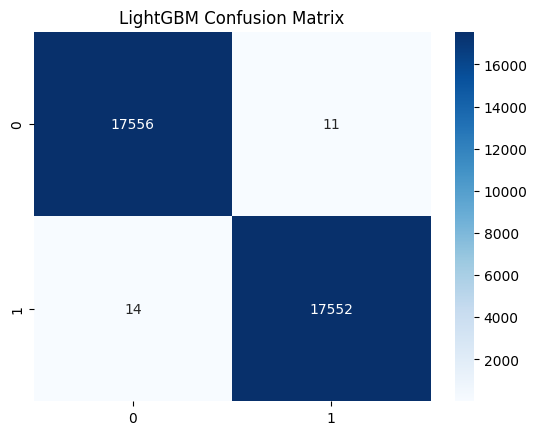

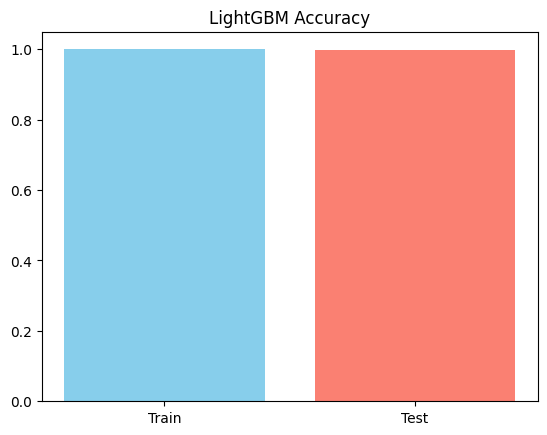



[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8


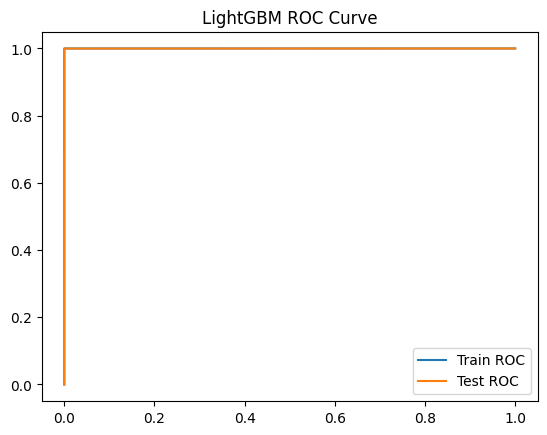

In [ ]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print("LightGBM Train Acc:", train_acc)
print("LightGBM Test Acc:", test_acc)

print("\n")

#Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title("LightGBM Confusion Matrix"); plt.show()

print("\n")

#Bar graph
plt.bar(["Train","Test"], [train_acc, test_acc], color=['skyblue','salmon'])
plt.title("LightGBM Accuracy"); plt.show()

print("\n")

#ROC Curve
y_train_proba = lgbm.predict_proba(X_train)[:,1]
y_test_proba = lgbm.predict_proba(X_test)[:,1]
plt.plot(*roc_curve(y_train, y_train_proba)[:2], label="Train ROC")
plt.plot(*roc_curve(y_test, y_test_proba)[:2], label="Test ROC")
plt.legend(); plt.title("LightGBM ROC Curve"); plt.show()


**Support Vector Machine:**

SVM classification showed good results because of its flexibility in dealing with complex data distributions. SVM model also has accuracy which is seen from the spread (0.97 → 0.93). This narrow spread shows the model generalizes well and isn't overly sensitive to data distribution, while using 5-fold Cross-Validation and gives a mean accuracy of 0.96. All because the SVM able to find a subtle and difficult decision boundaries that can distinguish anomalies from normal cases with lowover fitting or high variance-bias. The high accuracy across folds suggests the chosen hyperparameters are well-tuned

In [ ]:

svm = SVC(kernel='rbf', C=10, gamma=0.1, random_state=42)
svm.fit(X_train, y_train)


SVC(C=10, gamma=0.1, random_state=42)

Cross-validated Accuracy scores: [0.9986053  0.99729599 0.99934534 0.99866223 0.99763748]
Mean Accuracy: 0.998309268422745




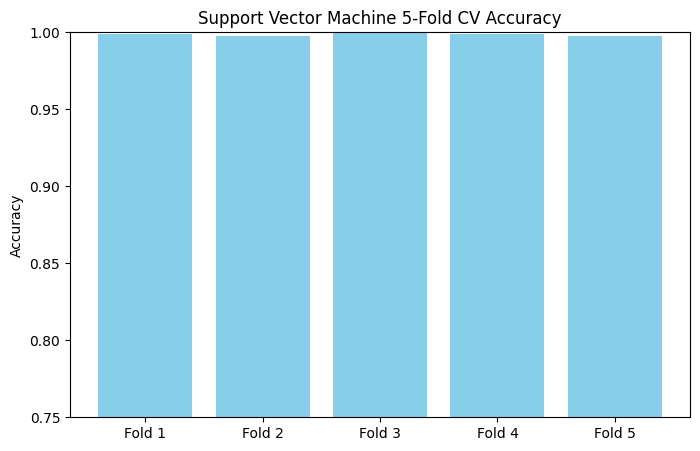

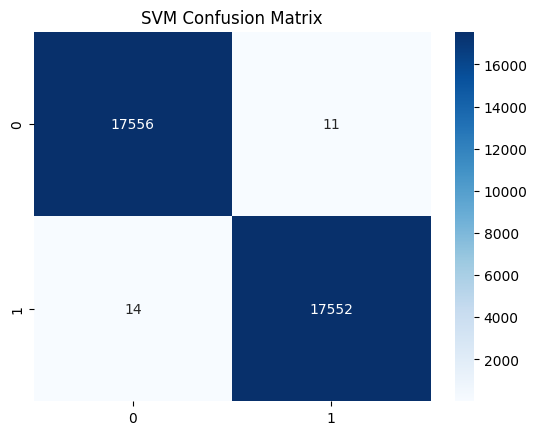

In [ ]:
acc_scores = cross_val_score(svm, X_pca, y_resampled, cv=5, scoring='accuracy')
print("Cross-validated Accuracy scores:", acc_scores)
print("Mean Accuracy:", acc_scores.mean())

print("\n")

plt.figure(figsize=(8,5))
plt.bar(range(1,6), acc_scores, color='skyblue')
plt.xticks(range(1,6), [f'Fold {i}' for i in range(1,6)])
plt.ylabel('Accuracy')
plt.title('Support Vector Machine 5-Fold CV Accuracy')
plt.ylim(0.75,1.0)
plt.show()

print("\n")

sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix"); plt.show()
